In [4]:
import os

home = '/Users/nastagetman'
found_paths = []

for root, dirs, files in os.walk(home):
    # Пропускаем системные и тяжёлые папки
    if any(skip in root for skip in ['/Library', '/.venv', '/venv', '/.git', '/node_modules']):
        continue
    for f in files:
        if f == 'fixed_values_ds.csv':
            found_paths.append(os.path.join(root, f))

print("Найдено файлов:", len(found_paths))
for p in found_paths:
    print(p)

Найдено файлов: 1
/Users/nastagetman/Downloads/‹ ¡®à â®à­ ï à ¡®â  1/fixed_values_ds.csv


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Автоматически находим файл
home = '/Users/nastagetman'
found_path = None

for root, dirs, files in os.walk(home):
    if any(skip in root for skip in ['/Library', '/.venv', '/venv', '/.git', '/node_modules']):
        continue
    if 'fixed_values_ds.csv' in files:
        found_path = os.path.join(root, 'fixed_values_ds.csv')
        break

print("Файл найден:", found_path)

# Загружаем данные
df = pd.read_csv(found_path)

print(df.head())
print(f"Размер данных: {df.shape}")
print(df.isnull().sum())
print(df['result'].value_counts())

Файл найден: /Users/nastagetman/Downloads/‹ ¡®à â®à­ ï à ¡®â  1/fixed_values_ds.csv
   having_ip_address  length_of_url  shortening_services  having_at_symbol  \
0                 -1             -1                   -1                -1   
1                 -1              0                   -1                -1   
2                 -1             -1                   -1                -1   
3                 -1             -1                   -1                -1   
4                 -1              1                   -1                -1   

   double-slash_redirection  prefix and suffix  sub_domains  ssl_state  \
0                        -1                 -1            1          1   
1                        -1                  1            0         -1   
2                        -1                 -1           -1         -1   
3                        -1                 -1           -1         -1   
4                        -1                  1            1         -1   

  

In [6]:
X = df.drop('result', axis=1)  # Все колонки, кроме 'result'
y = df['result']               # Целевая переменная

In [7]:
from sklearn.model_selection import train_test_split

# 80% данных — на обучение, 20% — на проверку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Вариант 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Вариант 2: XGBoost (может потребовать установки xgboost)
# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# xgb_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 0.9241
              precision    recall  f1-score   support

          -1       0.92      0.93      0.92      1409
           1       0.93      0.92      0.92      1410

    accuracy                           0.92      2819
   macro avg       0.92      0.92      0.92      2819
weighted avg       0.92      0.92      0.92      2819



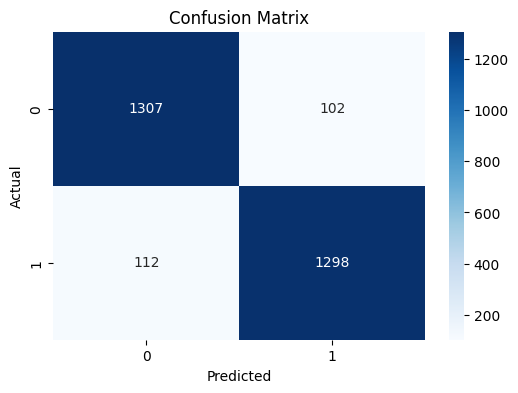

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Делаем предсказания
y_pred = rf_model.predict(X_test)

# Считаем точность
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Выводим подробный отчёт по метрикам (precision, recall, f1-score)
print(classification_report(y_test, y_pred))

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()